In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
from prophet.diagnostics import cross_validation, performance_metrics

In [55]:
df = pd.read_csv('/kaggle/input/crypto/BTC-USD (1).csv')

In [56]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-01-01,46311.746094,47827.312500,46288.484375,47686.812500,47686.812500,24582667004
1,2022-01-02,47680.925781,47881.406250,46856.937500,47345.218750,47345.218750,27951569547
2,2022-01-03,47343.542969,47510.726563,45835.964844,46458.117188,46458.117188,33071628362
3,2022-01-04,46458.851563,47406.546875,45752.464844,45897.574219,45897.574219,42494677905
4,2022-01-05,45899.359375,46929.046875,42798.222656,43569.003906,43569.003906,36851084859


In [57]:
df.dtypes

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

In [58]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,366.000000,366.000000,366.000000,366.000000,366.000000,3.660000e+02
mean,28246.638992,28784.507572,27586.784527,28166.134771,28166.134771,2.995652e+10
std,10227.603040,10440.484214,9973.936716,10202.005798,10202.005798,1.263602e+10
min,15782.300781,16253.047852,15599.046875,15787.284180,15787.284180,9.244362e+09
25%,19547.362793,20038.028809,19151.910644,19544.809082,19544.809082,2.228343e+10
50%,23171.639649,23514.309570,22716.174804,23164.473633,23164.473633,2.810729e+10
75%,39136.011719,39833.101562,38113.451172,39054.864258,39054.864258,3.435698e+10
max,47680.925781,48086.835938,47100.437500,47686.812500,47686.812500,1.189925e+11


In [61]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [63]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace = True)
df

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-01,46311.746094,47827.312500,46288.484375,47686.812500,47686.812500,24582667004
2022-01-02,47680.925781,47881.406250,46856.937500,47345.218750,47345.218750,27951569547
2022-01-03,47343.542969,47510.726563,45835.964844,46458.117188,46458.117188,33071628362
2022-01-04,46458.851563,47406.546875,45752.464844,45897.574219,45897.574219,42494677905
2022-01-05,45899.359375,46929.046875,42798.222656,43569.003906,43569.003906,36851084859
...,...,...,...,...,...,...
2022-12-28,16716.400391,16768.169922,16497.556641,16552.572266,16552.572266,17005713920
2022-12-29,16552.322266,16651.755859,16508.683594,16642.341797,16642.341797,14472237479
2022-12-30,16641.330078,16643.427734,16408.474609,16602.585938,16602.585938,15929162910


In [98]:
df.index.month_name()

Index(['January', 'January', 'January', 'January', 'January', 'January',
       'January', 'January', 'January', 'January',
       ...
       'December', 'December', 'December', 'December', 'December', 'December',
       'December', 'December', 'December', 'January'],
      dtype='object', name='Date', length=366)

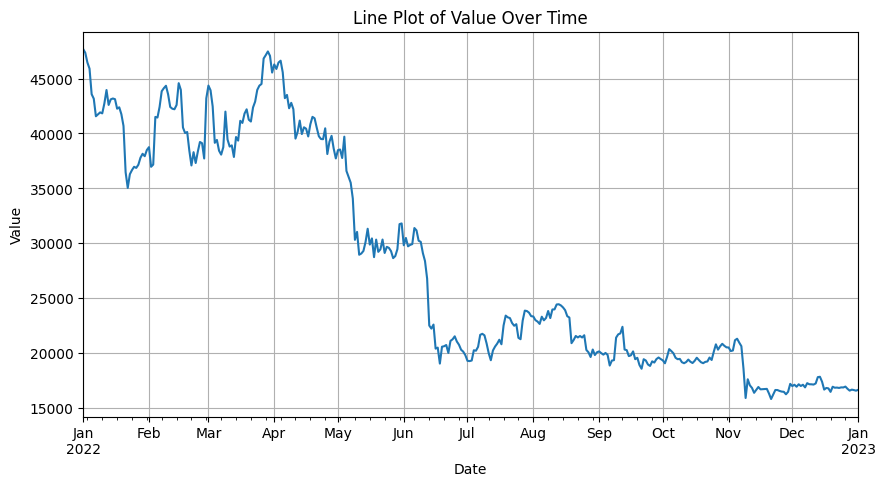

In [75]:
df['Close'].plot(kind='line', figsize=(10,5))
plt.title("Line Plot of Value Over Time")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [80]:
df1 = df[['Close']].reset_index() 
df1.columns = ['ds', 'y']
df1.dtypes

ds    datetime64[ns]
y            float64
dtype: object

In [99]:
train = df1[:-60]
test = df1[-60:]

In [100]:
model = Prophet()
model.fit(train)

08:11:11 - cmdstanpy - INFO - Chain [1] start processing
08:11:11 - cmdstanpy - INFO - Chain [1] done processing


In [103]:
future = model.make_future_dataframe(periods=60)
forecast = model.predict(future)

# Compare forecast with actual test data
y_true = test['y'].values
y_pred = forecast['yhat'][-60:].values

# Calculate error (e.g., RMSE)
rmse = mean_squared_error(y_true, y_pred, squared=False)
print(f"Test RMSE: {rmse}")


Test RMSE: 1747.907272351752


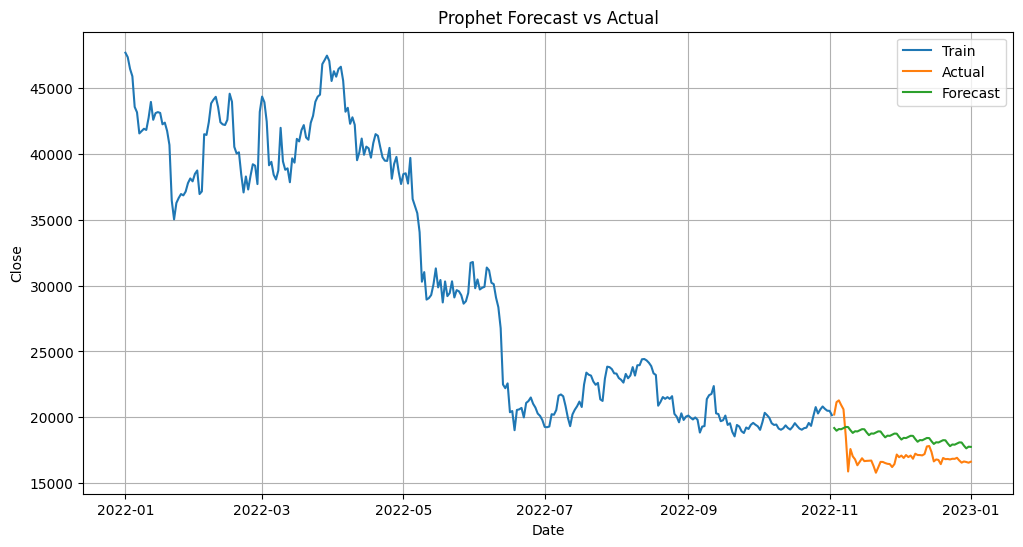

In [104]:
plt.figure(figsize=(12,6))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Actual', marker='')
plt.plot(test['ds'], y_pred, label='Forecast', marker='')
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Prophet Forecast vs Actual')
plt.legend()
plt.grid(True)
plt.show()